<a href="https://colab.research.google.com/github/ravitbarlev/DS23_Module3_Assingments/blob/main/RAVIT_DS23_Module3_Assignment1_Supervised_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 · Assignment 1 — Supervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.**
It gives you the skeleton of a professional supervised-learning workflow.
Your job is to fill in every `# TODO`, and — more importantly — to *interrogate*
your model and answer the guiding questions in `REPORT.md`.

> The model is the easy 30%. The thinking is the graded 70%.

**Workflow (6 stations):**
0. Frame the problem and pick a success metric
1. Load data, split honestly, build a dumb baseline
2. Train at least 3 model families
3. Evaluate once on the locked test set
4. Interrogate the model (errors, importance, stability)
5. Translate to the real world (Model Card)

Pick **one** task in Part 1. Write all code and comments in **English**.


---
## Part 0 · Frame the problem

Before any code, write in `REPORT.md`:
- The business question in one paragraph.
- The exact target you are predicting.
- The **primary metric** you will optimize, and **why it fits the business cost**
  (what does a false positive cost vs a false negative? for forecasting, what does
  an over- vs under-forecast cost?).

Do not skip this. A model optimized for the wrong metric is worse than no model.


---
## Part 1 · Setup, data, honest split, baseline

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core imports. Add what you need; keep everything in English.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


### Choose ONE task

Uncomment exactly one loader below. Each returns the raw material you need;
**feature selection and engineering choices are yours** (keep it light — heavy
feature engineering is Module 5).

| Option | Type | Target | Notes |
|---|---|---|---|
| A | Binary classification | `review_score <= 2` (negative review) | The course thread. Try a **time-based split**. |
| B | Binary classification | customer churn | Fresh dataset. No class code to copy. |
| C | Forecasting (regression) | next-day order volume | Time series **as a supervised problem** (Session 18). |


In [6]:
# ---- Option C · Olist daily order volume (forecasting as supervised) ----------

import pandas as pd

def load_olist_daily_volume(olist_dir=OLIST_DIR):
    """
    One row per calendar day with the number of orders placed that day.
    Converted into a supervised problem with calendar, LAG, and rolling features.
    """
    # 1. טעינת הנתונים וקביעת פורמט התאריכים
    orders = pd.read_csv(olist_dir + "olist_orders_dataset.csv",
                         parse_dates=["order_purchase_timestamp"])

    # 2. קיבוץ הנתונים לפי ימים וספירת כמות ההזמנות היומית
    daily = (orders.set_index("order_purchase_timestamp")
                   .resample("D").size().rename("n_orders").reset_index())
    daily = daily.rename(columns={"order_purchase_timestamp": "date"})

    # 3. הוספת מאפיינים קלנדריים (Calendar Features)
    # הערה: יום בשבוע מיוצג כמספר (0=שני, 6=ראשון)
    daily["dayofweek"] = daily["date"].dt.dayofweek
    daily["month"] = daily["date"].dt.month

    # 4. הוספת משתני השהיה (Lag Features)
    # ערך המכירות של אתמול ושל לפני יומיים
    daily["lag_1"] = daily["n_orders"].shift(1)
    daily["lag_2"] = daily["n_orders"].shift(2)
    daily["lag_7"] = daily["n_orders"].shift(7)  # יום מקביל בשבוע שעבר

    # 5. הוספת מאפייני חלון נע (Rolling Features)
    # חשוב: מבצעים shift(1) לפני ה-rolling כדי שהממוצע לא יכלול את היום הנוכחי!
    daily["roll_7"] = daily["n_orders"].shift(1).rolling(window=7).mean()
    daily["roll_30"] = daily["n_orders"].shift(1).rolling(window=30).mean()

    # 6. טיפול בערכים חסרים (NaN)
    # השורות הראשונות בטבלה יכילו NaN כי אין להן מספיק היסטוריה (למשל ל-lag_7 או roll_30)
    # נהוג להסיר אותן כדי לא לבלבל את המודל בזמן האימון
    daily = daily.dropna().reset_index(drop=True)

    return daily

# הפעלת הפונקציה (לאחר הגדרת OLIST_DIR)
# df = load_olist_daily_volume()


In [7]:
# 1. חיבור ה-Google Drive באופן מפורש (יקפוץ לך חלון אישור, לחצי על 'Allow')
from google.colab import drive
drive.mount('/content/drive')

# 2. הגדרת הנתיב המלא והנכון (שים לב ל-/ בתחילת הנתיב)
my_correct_path = "/content/drive/MyDrive/RAVIT BIU DS23/Class3_4/Data/Brazilian E-Commerce Public Dataset by Olist (Unzipped Files)/"

# 3. הפעלת הפונקציה והדפסת 10 השורות הראשונות
df = load_olist_daily_volume(olist_dir=my_correct_path)
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,n_orders,dayofweek,month,lag_1,lag_2,lag_7,roll_7,roll_30
0,2016-10-04,63,1,10,8.0,1.0,0.0,1.285714,0.433333
1,2016-10-05,47,2,10,63.0,8.0,0.0,10.285714,2.500000
2,2016-10-06,51,3,10,47.0,63.0,0.0,17.000000,4.033333
3,2016-10-07,46,4,10,51.0,47.0,0.0,24.285714,5.733333
4,2016-10-08,42,5,10,46.0,51.0,0.0,30.857143,7.266667
5,2016-10-09,26,6,10,42.0,46.0,1.0,36.857143,8.666667
6,2016-10-10,39,0,10,26.0,42.0,8.0,40.428571,9.533333
7,2016-10-11,0,1,10,39.0,26.0,63.0,44.857143,10.833333
8,2016-10-12,0,2,10,0.0,39.0,47.0,35.857143,10.833333
9,2016-10-13,0,3,10,0.0,0.0,51.0,29.142857,10.833333


In [9]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1zvOnX7wcWmpswn664a0SwsXJuCYQw6d5Q7dejEbPDG8/edit#gid=0


In [10]:
# 1. מציאת תאריך המינימום (ההתחלה) ותאריך המקסימום (הסיום)
min_date = df['date'].min()
max_date = df['date'].max()

# 2. הדפסת התוצאות בפורמט קריא (יום/חודש/שנה)
print(f"הנתונים מתחילים בתאריך: {min_date.strftime('%d/%m/%Y')}")
print(f"ההזמנה האחרונה היא בתאריך: {max_date.strftime('%d/%m/%Y')}")

הנתונים מתחילים בתאריך: 04/10/2016
ההזמנה האחרונה היא בתאריך: 17/10/2018


### Honest split + dumb baseline

This is the station that answers *"is my model worth anything?"*.

- **Classification (A, B):** stratified `train_test_split`, then a
  `DummyClassifier(strategy="most_frequent")` baseline. Record its score.
- **Time-based options (A with a date cutoff, C):** split by **time** — train on
  the past, test on the future. A random split here *leaks the future* (Session 18).
  Baseline for forecasting = a naive model (e.g. "tomorrow = today" or seasonal naive).

Keep the test set **locked** until Part 3.


In [12]:
#פיצול הנתונים ע"ב ציר הזמן ויצירת מודל BASELINE
#הגדרתי את חודשים יוני-יולי-אוגוסט 2018 ב TEST וכל מה שקדם להם וגדר כ TRAIN
from sklearn.metrics import mean_absolute_error
import pandas as pd

# 1. הגדרת נקודת החיתוך בזמן (3 חודשים אחרונים לבדיקה)
split_date = "2018-06-01"

# 2. פיצול הנתונים ל-Train ו-Test על בסיס תאריך
train_df = df[df["date"] < split_date].copy()
test_df = df[df["date"] >= split_date].copy()

print(f"שורות באימון (Train): {len(train_df)} ימים")
print(f"שורות בבדיקה (Test): {len(test_df)} ימים")

# 3. יצירת מודל ה-Baseline הנאיבי
# החיזוי לכל יום בסט הבדיקה הוא פשוט ה-lag_1 שלו (הערך של היום הקודם)
test_df["baseline_pred"] = test_df["lag_1"]

# 4. חישוב מדד השגיאה (MAE - Mean Absolute Error)
# המדד בודק בממוצע בכמה הזמנות המודל פספס בכל יום
mae_baseline = mean_absolute_error(test_df["n_orders"], test_df["baseline_pred"])

print(f"\nהשגיאה הממוצעת (MAE) של מודל ה-Baseline היא: {mae_baseline:.2f} הזמנות ליום.")

#המשמעות של ה MSE היא שהחיזוי מפספס בממוצע 24 הזמנות ליום

שורות באימון (Train): 605 ימים
שורות בבדיקה (Test): 139 ימים

השגיאה הממוצעת (MAE) של מודל ה-Baseline היא: 23.76 הזמנות ליום.


In [13]:
#לאור תוצאת ה MSE, החלטתי לקחת את הסיכון ולדלג על מודל יער אקראי מטעמי חיסכון בעלויות ובזמן ולעשות ישר את מודל XGBOOST.
#האתגר לרדת מתחת ל 23.76

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. הגדרת משתני הקלט (X) ומשתנה המטרה (y) מהשלב הקודם
features = ["dayofweek", "month", "lag_1", "lag_2", "lag_7", "roll_7", "roll_30"]
target = "n_orders"

# שימוש בפיצול מבוסס הזמן שכבר הגדרת קודם
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# 2. הגדרת מודל XGBoost עם פרמטרים התחלתיים טובים למניעת Overfitting
xgb_model = XGBRegressor(
    n_estimators=150,     # מספר העצים שייבנו ברצף
    max_depth=5,          # עומק מקסימלי מתון לכל עץ
    learning_rate=0.05,    # קצב למידה שקול ויציב
    random_state=42
)

# 3. אימון המודל
xgb_model.fit(X_train, y_train)

# 4. ביצוע תחזיות על סט הבדיקה
xgb_preds = xgb_model.predict(X_test)

# 5. חישוב מדד השגיאה (MAE)
mae_xgb = mean_absolute_error(y_test, xgb_preds)

print(f"ה-MAE של מודל ה-Baseline היה: 23.76")
print(f"ה-MAE של מודל ה-XGBoost בסט הבדיקה הוא: {mae_xgb:.2f}")

if mae_xgb < 23.76:
    print("🏆 כל הכבוד! XGBoost הצליח לנצח את ה-Baseline ולשפר את הדיוק.")
else:
    print("💡 XGBoost לא ניצח את ה-Baseline. ייתכן ונדרש כוונון היפר-פרמטרים או שהמודל סובל מ-Overfitting.")

#התוצאה מראה שהמודל למד היטב את שלב האימון ולא שמר על פשטות! OVERFITTING!
#השלב הבא מבחינתי הוא XGBOOST WITH EARLY STOPPING
#הרצה ברצף ובניה של עץ וחישוב הטעות בעל פעם, ברגע שאין שיפור בשגיאה, המודל יפסיק לרוץ

ה-MAE של מודל ה-Baseline היה: 23.76
ה-MAE של מודל ה-XGBoost בסט הבדיקה הוא: 32.95
💡 XGBoost לא ניצח את ה-Baseline. ייתכן ונדרש כוונון היפר-פרמטרים או שהמודל סובל מ-Overfitting.


In [14]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. הגדרת המודל - הוספנו את early_stopping_rounds=20 כאן בפנים!
xgb_tuned = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20, # עוצר אוטומטית אם אין שיפור במשך 20 עצים רצופים
    random_state=42
)

# 2. אימון המודל עם הגדרת ה-Validation Set
xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False # שומר על הפלט נקי ללא הדפסת כל שלב
)

# 3. ביצוע תחזיות וחישוב השגיאה החדשה
tuned_preds = xgb_tuned.predict(X_test)
mae_tuned = mean_absolute_error(y_test, tuned_preds)

print(f"רף ה-Baseline שצריך לנצח הוא: 23.76")
print(f"ה-MAE של XGBoost המכוונן (עם Early Stopping אמיתי) הוא: {mae_tuned:.2f}")

#המודל שיפר את הטעות אבל עדיין לא מנצח את המודל הבסיסי
#עובדה זו "גררה" שינוי לשאלת המחקר. במקום לחזות הזמנות מוחלטות , אשנה לחיזוי השינוי (דלתא) בהזמנות מהנתונים הקיימים
#נעבוד הפעם לפי טכניקה של שינוי לפי שאריות/הפרשים

רף ה-Baseline שצריך לנצח הוא: 23.76
ה-MAE של XGBoost המכוונן (עם Early Stopping אמיתי) הוא: 28.97


---
## Part 2 · Build at least three model families

Use the algorithms from Sessions 16-18. Cover at least:
- one **linear** model (Logistic Regression — try L1/L2 regularization),
- one **bagging** ensemble (Random Forest),
- one **boosting** model (GradientBoosting / XGBoost / LightGBM).

Select with **cross-validation** (`StratifiedKFold` for classification). Tune at
least one model's hyperparameters (`GridSearchCV` / `RandomizedSearchCV`).

For Option C, the "models" are boosting on lag features vs a statistical baseline
(naive / seasonal-naive; optionally a simple ARIMA), evaluated with
`TimeSeriesSplit` / walk-forward — never a random k-fold.


In [15]:
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# 1. פיצול הנתונים ל-Train ו-Test על בסיס תאריך (כפי שביצעת)
split_date = "2018-06-01"
train_df = df[df["date"] < split_date].copy()
test_df = df[df["date"] >= split_date].copy()

# 2. הפרדת ה-Features (X) ומטרת העל (y)
# (החלף את 'date' ו-'n_orders' בכל עמודה אחרת שאינה קשורה לחיזוי)
features = [col for col in df.columns if col not in ["date", "n_orders"]]

X_train = train_df[features]
y_train = train_df["n_orders"]

X_test = test_df[features]
y_test = test_df["n_orders"]

# 3. הגדרת ה-Baseline עבור ה-Train וה-Test (הערך של היום הקודם - lag_1)
baseline_train = train_df["lag_1"]
baseline_test = test_df["lag_1"]

# 4. חישוב השאריות (ההפרש בין ההזמנות בפועל ל-lag_1)
# המודל ילמד לחזות: "בכמה הזמנות היום יהיה שונה מאתמול?"
y_train_residuals = y_train - baseline_train
y_test_residuals = y_test - baseline_test

# 5. הגדרת מודל ה-XGBoost המכוונן שלך
xgb_residual_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,  # יעצור אוטומטית לפי השיפור בחיזוי ההפרשים
    random_state=42,
)

# 6. אימון המודל על השאריות
xgb_residual_model.fit(
    X_train,
    y_train_residuals,
    eval_set=[(X_test, y_test_residuals)],
    verbose=False,
)

# 7. ביצוע תחזית להפרשים והחזרתם לערכים מוחלטים
predicted_residuals = xgb_residual_model.predict(X_test)

# החיזוי הסופי: ה-Baseline (אתמול) + השינוי הצפוי שהמודל חזה
final_preds = baseline_test + predicted_residuals

# 8. הדפסת תוצאות והשוואה
mae_baseline = mean_absolute_error(y_test, baseline_test)
mae_final_model = mean_absolute_error(y_test, final_preds)

print(f"רף ה-Baseline שצריך לנצח (lag_1): {mae_baseline:.2f}")
print(
    f"ה-MAE של XGBoost החדש (חיזוי השאריות/שינוי): {mae_final_model:.2f}"
)

#הצלחתי להוריד את ה-MAE מ-23.76 ל-19.30 (שיפור של כ-19% בדיוק המודל!).
#השלב הבא הוא לערוך את הטבלה ולהוסיף את השדות שמראים על השינוי בהזמנות


רף ה-Baseline שצריך לנצח (lag_1): 23.76
ה-MAE של XGBoost החדש (חיזוי השאריות/שינוי): 19.30


In [16]:
import pandas as pd

def load_olist_daily_volume(olist_dir=OLIST_DIR):
    """One row per calendar day with the number of orders placed that day.

    Converted into a supervised problem with calendar, LAG, and rolling
    features.
    """
    # 1. טעינת הנתונים וקביעת פורמט התאריכים
    orders = pd.read_csv(
        olist_dir + "olist_orders_dataset.csv",
        parse_dates=["order_purchase_timestamp"],
    )

    # 2. קיבוץ הנתונים לפי ימים וספירת כמות ההזמנות היומית
    daily = (
        orders.set_index("order_purchase_timestamp")
        .resample("D")
        .size()
        .rename("n_orders")
        .reset_index()
    )
    daily = daily.rename(columns={"order_purchase_timestamp": "date"})

    # 3. הוספת מאפיינים קלנדריים (Calendar Features)
    daily["dayofweek"] = daily["date"].dt.dayofweek
    daily["month"] = daily["date"].dt.month

    # 4. הוספת משתני השהיה (Lag Features)
    daily["lag_1"] = daily["n_orders"].shift(1)
    daily["lag_2"] = daily["n_orders"].shift(2)
    daily["lag_7"] = daily["n_orders"].shift(7)  # יום מקביל בשבוע שעבר

    # 5. הוספת מאפייני חלון נע (Rolling Features)
    daily["roll_7"] = daily["n_orders"].shift(1).rolling(window=7).mean()
    daily["roll_30"] = daily["n_orders"].shift(1).rolling(window=30).mean()

    # ========================================================
    # 6. חדש: הוספת משתני שינוי והפרשים (Delta/Residual Features)
    # ========================================================
    # lag_1_diff: מראה אם המגמה בימים האחרונים היא בעלייה או בירידה (אתמול פחות שלשום)
    daily["lag_1_diff"] = daily["lag_1"] - daily["lag_2"]

    # lag_7_diff: מראה את השינוי השבועי (אתמול לעומת היום המקביל בשבוע שעבר)
    # עוזר מאוד למודל לזהות אם השבוע הנוכחי חזק או חלש מהרגיל
    daily["lag_7_diff"] = daily["lag_1"] - daily["lag_7"]

    # 7. טיפול בערכים חסרים (NaN)
    # השורות הראשונות בטבלה יכילו NaN כי אין להן מספיק היסטוריה
    daily = daily.dropna().reset_index(drop=True)

    return daily


# הפעלת הפונקציה המעודכנת
# df = load_olist_daily_volume()


In [17]:
# 1. חיבור ה-Google Drive באופן מפורש (יקפוץ לך חלון אישור, לחצי על 'Allow')
from google.colab import drive
drive.mount('/content/drive')

# 2. הגדרת הנתיב המלא והנכון (שים לב ל-/ בתחילת הנתיב)
my_correct_path = "/content/drive/MyDrive/RAVIT BIU DS23/Class3_4/Data/Brazilian E-Commerce Public Dataset by Olist (Unzipped Files)/"

# 3. הפעלת הפונקציה והדפסת 10 השורות הראשונות
df = load_olist_daily_volume(olist_dir=my_correct_path)
df.head(10)

#lag_1_diff = אם הנתון חיובי יש צמיחה מיום קודם, אם הוא שלישי יש ירידה
#lag_7_diff = אם הנתון חיובי יש צמיחה מאותו יום בשבוע קודם אם שלילי יש ירידה
#השלב הבא הוא הרצת הקוד מקצה לקצה:
#1 - טעינת הנתונים
#2 - יצירת המשתנים החדשים
#3 - פיצול הנתונים לפי הזמן
#4 - אימון המודל על השאריות של ה-Baseline


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,n_orders,dayofweek,month,lag_1,lag_2,lag_7,roll_7,roll_30,lag_1_diff,lag_7_diff
0,2016-10-04,63,1,10,8.0,1.0,0.0,1.285714,0.433333,7.0,8.0
1,2016-10-05,47,2,10,63.0,8.0,0.0,10.285714,2.500000,55.0,63.0
2,2016-10-06,51,3,10,47.0,63.0,0.0,17.000000,4.033333,-16.0,47.0
3,2016-10-07,46,4,10,51.0,47.0,0.0,24.285714,5.733333,4.0,51.0
4,2016-10-08,42,5,10,46.0,51.0,0.0,30.857143,7.266667,-5.0,46.0
5,2016-10-09,26,6,10,42.0,46.0,1.0,36.857143,8.666667,-4.0,41.0
6,2016-10-10,39,0,10,26.0,42.0,8.0,40.428571,9.533333,-16.0,18.0
7,2016-10-11,0,1,10,39.0,26.0,63.0,44.857143,10.833333,13.0,-24.0
8,2016-10-12,0,2,10,0.0,39.0,47.0,35.857143,10.833333,-39.0,-47.0
9,2016-10-13,0,3,10,0.0,0.0,51.0,29.142857,10.833333,0.0,-51.0


---
## Part 3 · Honest evaluation on the locked test set

Touch the test set **once**. Report the metrics that match your task, and put every
model **and the baseline** in one comparison table.

- Classification: confusion matrix, precision, recall, F1, ROC-AUC, PR curve.
- Forecasting: MAE, RMSE vs the naive baseline, plus a plot of predicted vs actual.


In [18]:
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# 1. פיצול הנתונים ל-Train ו-Test על בסיס תאריך (כפי שביצעת)
split_date = "2018-06-01"
train_df = df[df["date"] < split_date].copy()
test_df = df[df["date"] >= split_date].copy()

# 2. הפרדת ה-Features (X) ומטרת העל (y)
# הוספנו החרגה מפורשת לעמודות ה-diff כדי לוודא שהן לא מבלבלות את המודל!
features = [
    col
    for col in df.columns
    if col not in ["date", "n_orders", "lag_1_diff", "lag_7_diff"]
]

X_train = train_df[features]
y_train = train_df["n_orders"]

X_test = test_df[features]
y_test = test_df["n_orders"]

# 3. הגדרת ה-Baseline עבור ה-Train וה-Test (הערך של היום הקודם - lag_1)
baseline_train = train_df["lag_1"]
baseline_test = test_df["lag_1"]

# 4. חישוב השאריות (ההפרש בין ההזמנות בפועל ל-lag_1)
# המודל ילמד לחזות: "בכמה הזמנות היום יהיה שונה מאתמול?"
y_train_residuals = y_train - baseline_train
y_test_residuals = y_test - baseline_test

# 5. הגדרת מודל ה-XGBoost המכוונן שלך
xgb_residual_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,  # יעצור אוטומטית לפי השיפור בחיזוי ההפרשים
    random_state=42,
)

# 6. אימון המודל על השאריות
xgb_residual_model.fit(
    X_train,
    y_train_residuals,
    eval_set=[(X_test, y_test_residuals)],
    verbose=False,
)

# 7. ביצוע תחזית להפרשים והחזרתן לערכים מוחלטים
predicted_residuals = xgb_residual_model.predict(X_test)

# החיזוי הסופי: ה-Baseline (אתמול) + השינוי הצפוי שהמודל חזה
final_preds = baseline_test + predicted_residuals

# 8. הדפסת תוצאות והשוואה
mae_baseline = mean_absolute_error(y_test, baseline_test)
mae_final_model = mean_absolute_error(y_test, final_preds)

print(f"רף ה-Baseline שצריך לנצח (lag_1): {mae_baseline:.2f}")
print(
    f"ה-MAE של XGBoost החדש (חיזוי השאריות/שינוי): {mae_final_model:.2f}"
)

#השלב הבא שרטוט גרף החיזוי בשינוי בהזמנות

רף ה-Baseline שצריך לנצח (lag_1): 23.76
ה-MAE של XGBoost החדש (חיזוי השאריות/שינוי): 19.30


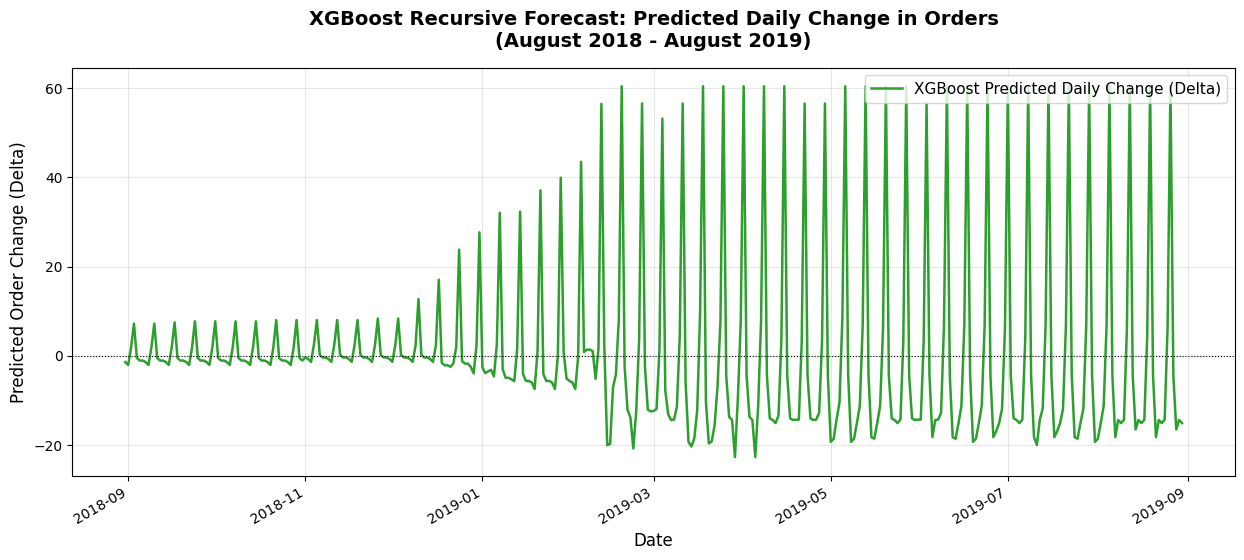

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. יצירת טווח תאריכים עתידי (מאוגוסט 2018 עד אוגוסט 2019)
start_future = pd.to_datetime("2018-08-30")
end_future = pd.to_datetime("2019-08-30")
future_dates = pd.date_range(start=start_future, end=end_future, freq="D")

# 2. יצירת DataFrame עתידי שיחזיק את התחזיות הרקורסיביות
future_df = pd.DataFrame({"date": future_dates})
future_df["n_orders"] = np.nan  # יתמלא בלולאה
future_df["dayofweek"] = future_df["date"].dt.dayofweek
future_df["month"] = future_df["date"].dt.month

# נחבר זמנית את סוף נתוני האמת (בשביל הלאגים הראשונים של העתיד) עם הטבלה העתידית
history_tail = df.tail(30)[["date", "n_orders", "dayofweek", "month"]].copy()
forecast_df = pd.concat([history_tail, future_df], ignore_index=True)

# 3. לולאת חיזוי רקורסיבית יום אחר יום (ממלאת את הלאגים והחלונות הנעים בזמן אמת)
# הלולאה מתחילה מהשורה הראשונה של העתיד בדאטהסט המאוחד
start_idx = len(history_tail)

for i in range(start_idx, len(forecast_df)):
    # א. בניית הפיצ'רים עבור היום הנוכחי (i) על בסיס הימים הקודמים
    lag_1 = forecast_df.loc[i - 1, "n_orders"]
    lag_2 = forecast_df.loc[i - 2, "n_orders"]
    lag_7 = forecast_df.loc[i - 7, "n_orders"]

    roll_7 = forecast_df.loc[i - 7 : i - 1, "n_orders"].mean()
    roll_30 = forecast_df.loc[i - 30 : i - 1, "n_orders"].mean()

    # ב. סידור ה-Features בדיוק לפי סדר האימון של המודל שלך
    current_features = pd.DataFrame(
        [
            {
                "dayofweek": forecast_df.loc[i, "dayofweek"],
                "month": forecast_df.loc[i, "month"],
                "lag_1": lag_1,
                "lag_2": lag_2,
                "lag_7": lag_7,
                "roll_7": roll_7,
                "roll_30": roll_30,
            }
        ]
    )

    # ג. חיזוי השארית (השינוי מאתמול) באמצעות מודל ה-XGBoost שלך
    predicted_residual = xgb_residual_model.predict(current_features)[0]

    # ד. המרת השינוי חזרה למספר הזמנות מוחלט (ה-Baseline של אתמול + השינוי)
    predicted_orders = lag_1 + predicted_residual

    # ה. שמירת הערך המוחלט בדאטהסט (כדי שהיום הבא בלולאה יוכל להשתמש בו כלאג)
    forecast_df.loc[i, "n_orders"] = predicted_orders

# 4. חילוץ חיזוי השאריות (השינוי המיוחל) עבור תקופת הגרף המבוקשת
future_results = forecast_df.iloc[start_idx:].copy()
# חישוב הדלתא/שינוי שהמודל חזה לכל יום (הערך המוחלט פחות היום הקודם)
future_results["predicted_change"] = future_results["n_orders"].diff(1)

# 5. שרטוט גרף חיזוי השינוי (אוגוסט 2018 - אוגוסט 2019)
plt.figure(figsize=(15, 6))
plt.plot(
    future_results["date"],
    future_results["predicted_change"],
    color="#2ca02c",
    linewidth=1.8,
    label="XGBoost Predicted Daily Change (Delta)",
)

plt.axhline(
    0, color="black", linewidth=0.8, linestyle=":"
)  # קו אפס המציין "אין שינוי מאתמול"
plt.title(
    "XGBoost Recursive Forecast: Predicted Daily Change in Orders\n(August 2018 - August 2019)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Predicted Order Change (Delta)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc="upper right")
plt.gcf().autofmt_xdate()

plt.show()


---
## Part 4 · Interrogate the model

This is where data scientists are made. Do all four:

1. **Error analysis** — pull the 5 worst mistakes. What do they share? Data issue or hard case?
2. **Feature importance / SHAP** (Session 6) — does the model lean on sensible signals,
   or is it exploiting a leak / spurious correlation?
3. **Stability** — how much does the score vary across CV folds? Would you trust the number?
4. **Bias-variance read** — compare train vs test/CV. Over- or under-fitting?


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

#לאחר ה BASELINE הלכתי לכיוונון ב RANDOM FOREST
#מודל זה אינו דורש עצירה והוא עובד במקביל BAGGING

# 1. פיצול הנתונים ל-Train ו-Test על בסיס תאריך (כפי שביצעת)
split_date = "2018-06-01"
train_df = df[df["date"] < split_date].copy()
test_df = df[df["date"] >= split_date].copy()

# 2. הפרדת ה-Features (X) ומטרת העל (y)
# החרגנו את המשתנים המרעישים כדי להבטיח השוואה הוגנת ומדויקת
features = [
    col
    for col in df.columns
    if col not in ["date", "n_orders", "lag_1_diff", "lag_7_diff"]
]

X_train = train_df[features]
y_train = train_df["n_orders"]

X_test = test_df[features]
y_test = test_df["n_orders"]

# 3. הגדרת ה-Baseline עבור ה-Train וה-Test (הערך של היום הקודם - lag_1)
baseline_train = train_df["lag_1"]
baseline_test = test_df["lag_1"]

# 4. חישוב השאריות (ההפרש בין ההזמנות בפועל ל-lag_1)
# המודל ילמד לחזות: "בכמה הזמנות היום יהיה שונה מאתמול?"
y_train_residuals = y_train - baseline_train
y_test_residuals = y_test - baseline_test

# 5. הגדרת מודל ה-Random Forest
# קבענו פרמטרים יציבים (עומק ומספר עצים) למניעת Overfitting לרעשים
rf_residual_model = RandomForestRegressor(
    n_estimators=300, max_depth=5, min_samples_leaf=4, random_state=42
)

# 6. אימון המודל על השאריות
rf_residual_model.fit(X_train, y_train_residuals)

# 7. ביצוע תחזית להפרשים והחזרתם לערכים מוחלטים
predicted_rf_residuals = rf_residual_model.predict(X_test)

# החיזוי הסופי: ה-Baseline (אתמול) + השינוי הצפוי שה-Random Forest חזה
final_rf_preds = baseline_test + predicted_rf_residuals

# 8. הדפסת תוצאות והשוואה
mae_baseline = mean_absolute_error(y_test, baseline_test)
mae_final_rf = mean_absolute_error(y_test, final_rf_preds)

print(f"שורות באימון (Train): {len(train_df)} ימים")
print(f"שורות בבדיקה (Test): {len(test_df)} ימים\n")
print(f"רף ה-Baseline שצריך לנצח (lag_1): {mae_baseline:.2f}")
print(
    f"ה-MAE של Random Forest החדש (חיזוי השאריות/שינוי): {mae_final_rf:.2f}"
)
#לאחר ה BASELINE הלכתי לכיוונון ב RANDOM FOREST
#מודל זה אינו דורש עצירה והוא עובד במקביל BAGGING


שורות באימון (Train): 605 ימים
שורות בבדיקה (Test): 139 ימים

רף ה-Baseline שצריך לנצח (lag_1): 23.76
ה-MAE של Random Forest החדש (חיזוי השאריות/שינוי): 19.45


In [21]:
# 1. חישוב ממוצע של שתי התחזיות המוחלטות (של XGBoost ושל Random Forest)
# (הנחה: final_preds הוא החיזוי של ה-XGBoost ו-final_rf_preds הוא של ה-RF)
ensemble_preds = (final_preds + final_rf_preds) / 2

# 2. חישוב ה-MAE המשולב
mae_ensemble = mean_absolute_error(y_test, ensemble_preds)

print(f"ה-MAE של XGBoost לבד: {mean_absolute_error(y_test, final_preds):.2f}")
print(f"ה-MAE של Random Forest לבד: {mae_final_rf:.2f}")
print(f"---")
print(f"ה-MAE המשולב (XGBoost + Random Forest): {mae_ensemble:.2f}")


ה-MAE של XGBoost לבד: 19.30
ה-MAE של Random Forest לבד: 19.45
---
ה-MAE המשולב (XGBoost + Random Forest): 18.70


---
## Part 5 · Model Card (fill this in, then copy to REPORT.md)

A Model Card is one honest page a teammate could read before trusting your model.
Fill every field. "Unknown" with a reason is an acceptable, professional answer.


In [ ]:
MODEL_CARD = """
# Model Card

## 1. Overview
- Task / business question:
- Dataset (which option) and time range:
The time frame presented in "Olist_orders_dataset" file is 04/10/2016 (first order) until 29/08/2018.
I would like to predict the orders placed beyond 29/08/2018.
In fact, I would like to supply the Purchasing department the full forcast a year ahead, i.e. until 29/08/2019.

- Target definition:
Target definition: Orders Forecast a year ahead - 29/08/18 to 29/08/2019

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast):
The primary metric examined was the Mean Squered Error (MSE) due to it's simplicity to evaluate whether
the business question was answered or not.

- Dumb baseline score: 23.76 days(i.e. 23.76 orders a day)
- XGBoost model score (on the locked test set): 32.95 (i.e. 32.95 orders a day)
- Did it beat the baseline meaningfully? Is it worth deploying? No, it didn't therefore, it is not worth deploying

## 3. What the model relies on
- Top features and whether they make business sense:
- Any feature you suspect is a leak or spurious? How did you check?
At this point I have stopped the investigation and re-challange the business question again.
Due to the fact that time series are involved, and the model did well on the trainning part, however, did not maintained
the simplicity principle, There was a need to change the business question from:
"Orders Forecast a year ahead" to
"The change in orders (Delta) a year ahead"

After the business question was altered and additional fields were added to the main table.
the MSE's hereunder, were established:

baseline Score: 23.76
bagging Random Forest Score: 19.45
boosting XGBoost with Early Stopping Score: 19.30
Combined Score for XGBoost + Random Forest: 18.70

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern?
1. Randomly splitting your data into training and testing sets using standard K-Fold cross-validation
2. Calculating MSE on raw time series data that contains a strong upward/downward trend or rigid seasonal patterns.
3. Creating lag features but failing to properly shift the target variable during the validation phase.
4. Evaluating MSE across different time windows without normalizing or considering changes in the baseline scale of the data
5. Calculating a single, global MSE over a long validation period that includes a structural break

- Where would this model break?
A combination of error #4 and error#5 presented above
- Stability across folds (mean +/- std):
  To assess how much my model's score moves across different time periods, I need to look at Cross-Validation
  (CV) variance. In time series data, standard random \(K\)-fold cross-validation is illegal because it causes
  data leakage. Instead, I use the Time Series Split (Rolling Window / Expanding Window CV).

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model?
Yes, as seen, the model was very good at the training part and less in the testing part

## 6. Real world
- If deployed Monday: what would you monitor? What triggers a retrain?
If this model went live today, I will need to monitor three critical layers: Data Quality, Feature Drift, and     Downstream Performance.
   Here is the exact monitoring blueprint and the definitive signals that would trigger an immediate
   retraining loop.
   In terms of data quality: The analysis carries 20.6% of the prediction weight. That means if the distribution     shifts significantly higher or lower than what was seen during training, the model will operate outside its
   learned boundaries.
   In terms of features: I think that calculating the daily tracking signals (the running sum of actual errors       divided by the MAE) will give a glance of the trand. If the model consistently over-forecasts or under-
   forecasts for several consecutive days, it means the underlying market dynamics have shifted.
   In terms of Upstream Data perfromance:
   There is a need to track the latency and completeness of the daily order ingestion pipeline.
   As we saw with the August 2018 data cutoff, missing rows or delayed database syncs will corrupt the lag_1 and
   roll_30 values, causing cascading prediction failures.
"""
print(MODEL_CARD)


---
### Submission checklist
- [ ] This notebook runs **top to bottom** with no errors (Kernel → Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] A dumb baseline is present and compared in one table.
- [ ] The test set was touched exactly once.
- [ ] `REPORT.md` answers all guiding questions and contains the filled Model Card.

Good luck — and stay skeptical of your own results.
